# Chapter 06: Circles and Spheres

Source orientation: printed pages 77-95; PDF pages 95-113. The source pages were rendered privately from the scanned PDF for orientation only. This notebook is original teaching prose, code, diagrams, and checks; it does not copy textbook text, exercises, screenshots, page crops, or figures.

## Chapter Goal

The chapter replaces some of the straight-line habits of Euclidean geometry with the language of circles, spheres, and one added point at infinity. By the end, a reader should be able to compute an inversion, predict when a line or circle becomes a line or circle, recognize orthogonal and coaxal circle pencils, build an Apollonius locus, and see why stereographic and elliptic-plane pictures are natural extensions rather than unrelated tricks.

## Computational Translation Guide

- A point inversion is the radial map `P -> k^2 P / |P|^2`. The core invariant is `OP * OP' = k^2` and the same formula applied twice returns the original point.
- A line or circle is treated as a generalized circle. Lines through the inversion center stay lines; other lines become circles through the center; circles through the center become lines; other circles become circles.
- Orthogonal circles are checked by tangent directions, equivalently by perpendicular radii at each intersection.
- Coaxal pencils are circle families with a common radical axis or limiting points. Their orthogonal pencils make the hidden coordinate system visible.
- An Apollonius circle is a level set of a distance ratio. The center and radius can be computed directly, then verified with sampled points.
- Circle-preserving transformations are tested as Mobius transformations on the extended complex plane. The numeric checks fit the image of each sampled generalized circle and verify a cross-ratio invariant.
- Sphere inversion is the same radial rule in three dimensions. Stereographic projection appears when a plane is inverted from a point on a sphere onto that sphere.
- The elliptic plane is modeled by antipodal pairs on a sphere. Lines become great circles, and a spherical triangle records area by angle excess.

## Compact Visual Storyboard

| Item | Concept | Artifact | Inspection target | Check |
| --- | --- | --- | --- | --- |
| 1 | Circle inversion | `figures/inversion_grid_and_point_pairs.png` | Grid lines bend into circles through the center while point pairs stay on rays. | Products and involution residuals. |
| 2 | Lines and circles under inversion | `figures/line_circle_image_lab.png` | Four generalized-circle cases side by side. | Circle or line equation residuals. |
| 3 | Orthogonal and coaxal pencils | `figures/orthogonal_coaxal_pencils.png` | Intersecting and nonintersecting pencils crossing at right angles. | Maximum cosine of intersection angle. |
| 4 | Apollonius loci | `figures/apollonius_ratio_loci.png` and `tables/apollonius_loci.csv` | Constant-ratio circles and the perpendicular-bisector limiting case. | Distance-ratio errors from sampled points. |
| 5 | Circle-preserving maps | `html/mobius_circle_preservation.html` | Generalized circles remain generalized circles after a Mobius map. | Fitted-circle residuals and cross-ratio error. |
| 6 | Sphere inversion, stereographic projection, and elliptic intuition | `html/sphere_inversion_stereographic.html` and `figures/elliptic_gnomonic_triangle.png` | A plane inverts to a sphere; great-circle lines project to straight lines. | Sphere/ray residuals and Girard area check. |


In [1]:
from pathlib import Path
import json
import math
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from IPython.display import Markdown, display
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp

CHAPTER_NO = 6
HERE = Path.cwd().resolve()
BOOK_ROOT = None
for candidate in [HERE, *HERE.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate Introduction-to-Geometry book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, artifact_path, display_artifact, ensure_chapter_artifact_dirs, write_csv, write_json
from utils.course import chapter_by_no

chapter = chapter_by_no(CHAPTER_NO)
ARTIFACT_DIRS = ensure_chapter_artifact_dirs(CHAPTER_NO, BOOK_ROOT)
plt.ioff()

artifact_records = {}
check_records = {}

def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()

def record(path, role, concept):
    path = Path(path)
    artifact_records[rel(path)] = {
        "artifact": path.name,
        "path": rel(path),
        "role": role,
        "concept": concept,
        "bytes": path.stat().st_size if path.exists() else 0,
    }
    return path

def savefig(fig, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return path

def norm(v):
    return np.linalg.norm(v, axis=-1)

def invert_points(points, radius=1.0, center=(0.0, 0.0)):
    points = np.asarray(points, dtype=float)
    center = np.asarray(center, dtype=float)
    shifted = points - center
    r2 = np.sum(shifted * shifted, axis=-1)
    out = np.full_like(shifted, np.nan, dtype=float)
    mask = r2 > 1e-14
    out[mask] = center + radius**2 * shifted[mask] / r2[mask, None]
    return out

def invert_points3(points, radius=1.0, center=(0.0, 0.0, 0.0)):
    points = np.asarray(points, dtype=float)
    center = np.asarray(center, dtype=float)
    shifted = points - center
    r2 = np.sum(shifted * shifted, axis=-1)
    out = np.full_like(shifted, np.nan, dtype=float)
    mask = r2 > 1e-14
    out[mask] = center + radius**2 * shifted[mask] / r2[mask, None]
    return out

def circle_points(center, radius, n=500, start=0.0, stop=2 * np.pi):
    t = np.linspace(start, stop, n)
    center = np.asarray(center, dtype=float)
    return np.column_stack([center[0] + radius * np.cos(t), center[1] + radius * np.sin(t)])

def line_points(point, direction, span=(-3.0, 3.0), n=400):
    t = np.linspace(span[0], span[1], n)
    point = np.asarray(point, dtype=float)
    direction = np.asarray(direction, dtype=float)
    return point + t[:, None] * direction

def fit_circle(points):
    points = np.asarray(points, dtype=float)
    x = points[:, 0]
    y = points[:, 1]
    A = np.column_stack([x, y, np.ones_like(x)])
    b = -(x * x + y * y)
    coef, *_ = np.linalg.lstsq(A, b, rcond=None)
    cx = -coef[0] / 2
    cy = -coef[1] / 2
    r2 = cx * cx + cy * cy - coef[2]
    radius = math.sqrt(max(r2, 0.0))
    residual = np.max(np.abs(np.sqrt((x - cx) ** 2 + (y - cy) ** 2) - radius))
    return np.array([cx, cy]), radius, float(residual)

def fit_line(points):
    points = np.asarray(points, dtype=float)
    center = points.mean(axis=0)
    _, _, vh = np.linalg.svd(points - center, full_matrices=False)
    normal = vh[-1]
    residual = np.max(np.abs((points - center) @ normal))
    return center, normal, float(residual)

def add_circle(ax, center, radius, **kwargs):
    ax.add_patch(Circle(center, radius, fill=False, **kwargs))

def circle_intersections(c0, r0, c1, r1):
    c0 = np.asarray(c0, dtype=float)
    c1 = np.asarray(c1, dtype=float)
    dvec = c1 - c0
    d = float(np.linalg.norm(dvec))
    if d == 0 or d > r0 + r1 or d < abs(r0 - r1):
        return np.empty((0, 2))
    a = (r0 * r0 - r1 * r1 + d * d) / (2 * d)
    h2 = r0 * r0 - a * a
    h = math.sqrt(max(h2, 0.0))
    p = c0 + a * dvec / d
    perp = np.array([-dvec[1], dvec[0]]) / d
    return np.vstack([p + h * perp, p - h * perp])

def apollonius_circle(A, B, mu):
    """Locus |P - B| = mu |P - A|. Returns (center, radius), or (None, None) for the line case."""
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    if abs(mu - 1.0) < 1e-12:
        return None, None
    center = (B - mu * mu * A) / (1.0 - mu * mu)
    radius = abs(mu) * float(np.linalg.norm(A - B)) / abs(1.0 - mu * mu)
    return center, radius

display(Markdown(f"Loaded **{chapter['title']}**. Artifact root: `{rel(ARTIFACT_DIRS['figures'].parent)}`"))


Loaded **Circles and Spheres**. Artifact root: `artifacts/chapter-06`

## 1. Inversion as a Measurable Radial Rule

For a circle of inversion with center `O` and radius `k`, every ordinary point `P` different from `O` has an inverse `P'` on the same ray with `OP * OP' = k^2`. This single product explains the visual behavior: points near `O` are sent far away, points outside move inward, and the inversion circle is fixed point by point. The figure below overlays a square grid with its inverse so the singular center and the bending of lines are visible at once.


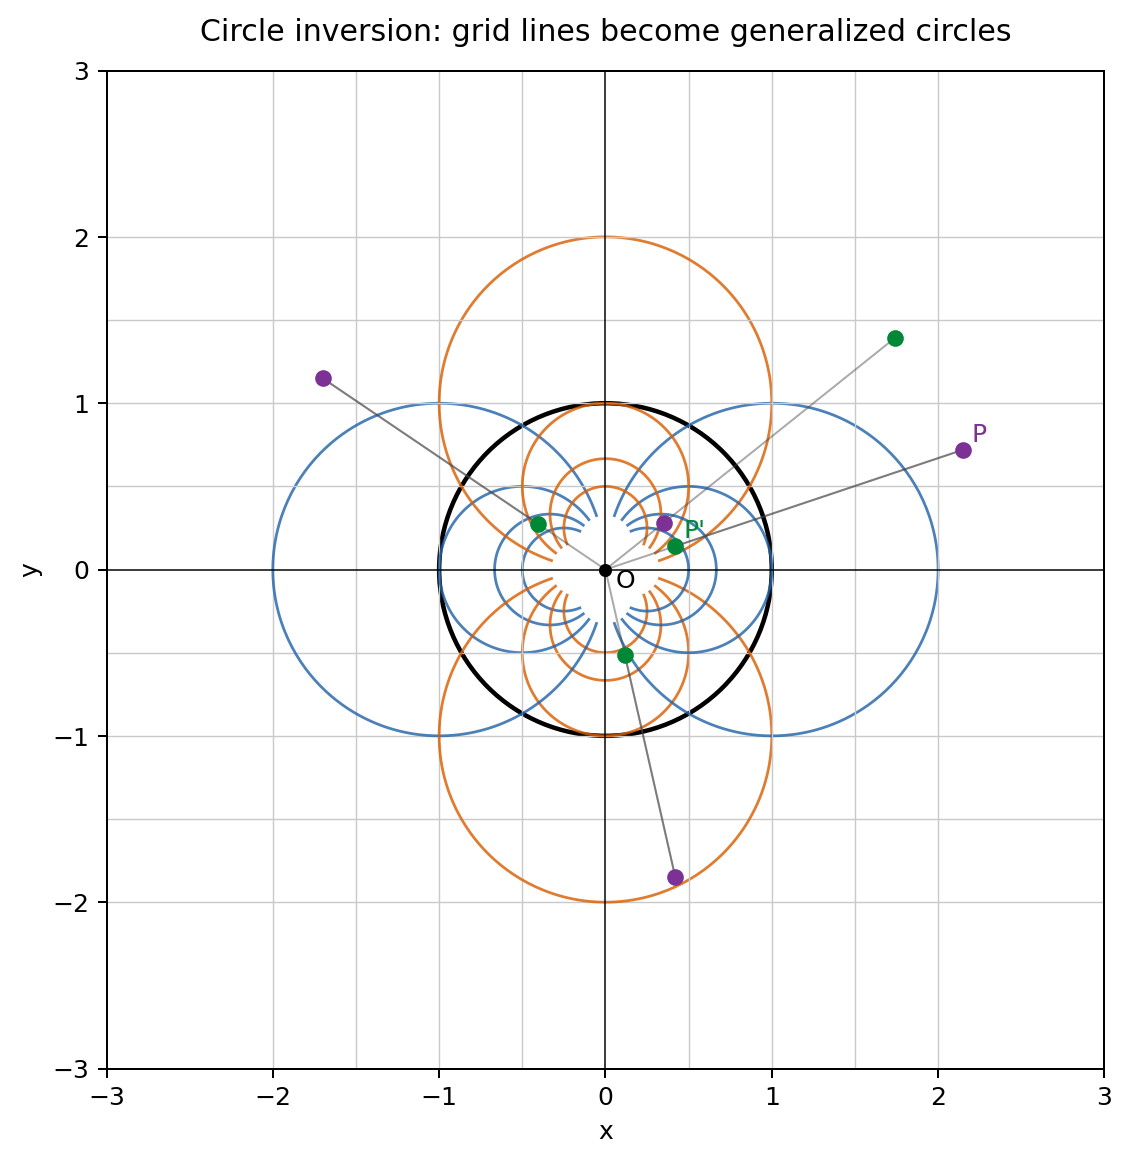

{'chapter': 6,
 'concept': 'circle inversion grid and point pairs',
 'inversion_radius': 1.0,
 'max_product_error': 1.1102230246251565e-16,
 'max_involution_error': 2.220446049250313e-16,
 'vertical_line_image_circle_center': [0.6666666666666666, 0.0],
 'vertical_line_image_radius': 0.6666666666666666,
 'line_image_circle_residual': 2.220446049250313e-16}

In [2]:
k = 1.0
fig, ax = plt.subplots(figsize=(7.2, 7.2))
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-3.0, 3.0)
ax.set_title("Circle inversion: grid lines become generalized circles", pad=12)
add_circle(ax, (0, 0), k, color="black", lw=1.8, linestyle="-", label="inversion circle")
ax.scatter([0], [0], color="black", s=18, zorder=5)
ax.text(0.06, -0.11, "O", fontsize=10)

coords = [-2.0, -1.5, -1.0, -0.5, 0.5, 1.0, 1.5, 2.0]
t = np.linspace(-3.0, 3.0, 900)
for c in coords:
    vertical = np.column_stack([np.full_like(t, c), t])
    horizontal = np.column_stack([t, np.full_like(t, c)])
    ax.plot(vertical[:, 0], vertical[:, 1], color="#c9c9c9", lw=0.55)
    ax.plot(horizontal[:, 0], horizontal[:, 1], color="#c9c9c9", lw=0.55)
    inv_v = invert_points(vertical, k)
    inv_h = invert_points(horizontal, k)
    good_v = np.isfinite(inv_v).all(axis=1) & (norm(inv_v) < 3.2)
    good_h = np.isfinite(inv_h).all(axis=1) & (norm(inv_h) < 3.2)
    ax.plot(inv_v[good_v, 0], inv_v[good_v, 1], color="#2364aa", lw=1.1, alpha=0.82)
    ax.plot(inv_h[good_h, 0], inv_h[good_h, 1], color="#d95f02", lw=1.1, alpha=0.82)

probe_points = np.array([[2.15, 0.72], [-1.7, 1.15], [0.42, -1.85], [0.35, 0.28]])
probe_inv = invert_points(probe_points, k)
for p0, q0 in zip(probe_points, probe_inv):
    ax.plot([0, p0[0]], [0, p0[1]], color="#444444", lw=0.8, alpha=0.45)
    ax.plot([p0[0], q0[0]], [p0[1], q0[1]], color="#444444", lw=0.8, alpha=0.45)
    ax.scatter([p0[0]], [p0[1]], color="#7b3294", s=32, zorder=6)
    ax.scatter([q0[0]], [q0[1]], color="#008837", s=32, zorder=6)
ax.text(probe_points[0, 0] + 0.05, probe_points[0, 1] + 0.05, "P", color="#7b3294")
ax.text(probe_inv[0, 0] + 0.05, probe_inv[0, 1] + 0.05, "P'", color="#008837")
ax.axhline(0, color="black", lw=0.6)
ax.axvline(0, color="black", lw=0.6)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(False)

products = norm(probe_points) * norm(probe_inv)
involution = invert_points(probe_inv, k)
line_sample = line_points((0.75, 0.0), (0.0, 1.0), span=(-2.5, 2.5), n=300)
line_image = invert_points(line_sample, k)
expected_center = np.array([1.0 / (2.0 * 0.75), 0.0])
expected_radius = abs(1.0 / (2.0 * 0.75))
line_image_residual = float(np.max(np.abs(norm(line_image - expected_center) - expected_radius)))

check = {
    "chapter": CHAPTER_NO,
    "concept": "circle inversion grid and point pairs",
    "inversion_radius": k,
    "max_product_error": float(np.max(np.abs(products - k * k))),
    "max_involution_error": float(np.max(norm(involution - probe_points))),
    "vertical_line_image_circle_center": expected_center.tolist(),
    "vertical_line_image_radius": expected_radius,
    "line_image_circle_residual": line_image_residual,
}
fig_path = artifact_path(CHAPTER_NO, "figures", "inversion_grid_and_point_pairs.png", BOOK_ROOT)
data_path = artifact_path(CHAPTER_NO, "data", "inversion_point_pairs.csv", BOOK_ROOT)
check_path = artifact_path(CHAPTER_NO, "checks", "inversion_grid_checks.json", BOOK_ROOT)
savefig(fig, fig_path)
rows = []
for idx, (p0, q0) in enumerate(zip(probe_points, probe_inv), start=1):
    rows.append({
        "pair": idx,
        "x": p0[0],
        "y": p0[1],
        "inverse_x": q0[0],
        "inverse_y": q0[1],
        "OP_times_OP_prime": norm(p0) * norm(q0),
    })
write_csv(data_path, rows)
write_json(check_path, check)
record(fig_path, "figure", "circle inversion grid")
record(data_path, "data", "sample point pairs")
record(check_path, "check", "circle inversion grid")
check_records["inversion_grid"] = check

display_artifact(fig_path, width=760)
check


## 2. Lines and Circles Under Inversion

In the inverse plane, a straight line is allowed to be a circle through the point at infinity. With that convention the rule is clean: inversion sends generalized circles to generalized circles. The next artifact keeps four cases separate so the exceptional cases are not hidden.

The plotted cases are: a line through `O`, a line not through `O`, a circle through `O`, and a circle not through `O`. The checks sample points from each original object, invert them, and measure how close the image is to its predicted line or circle.


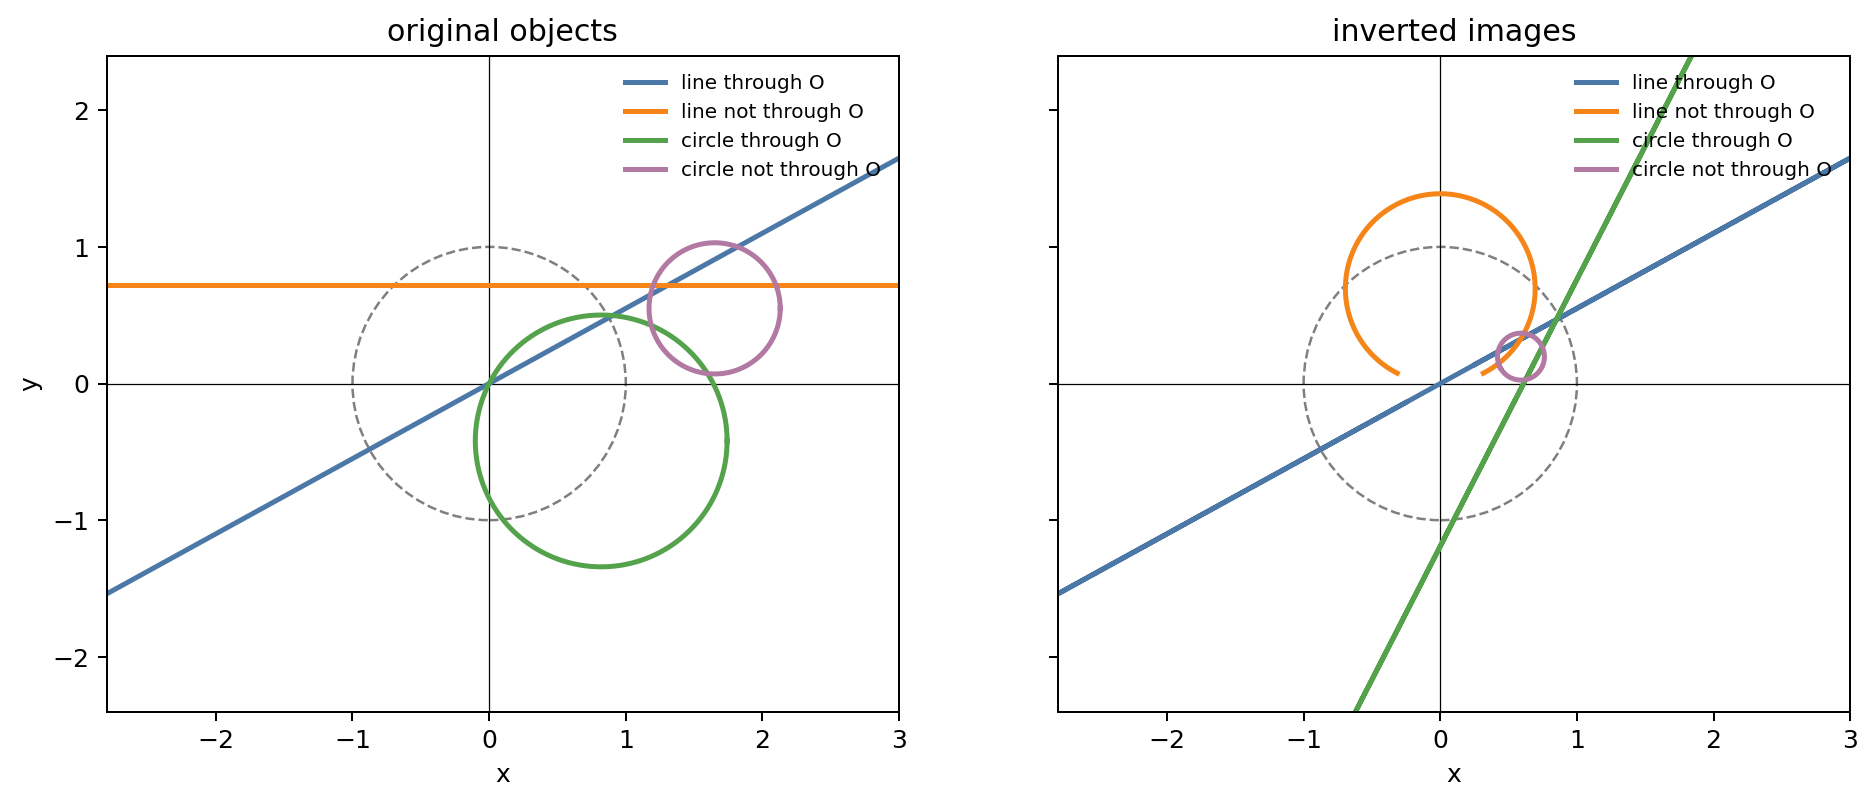

{'chapter': 6,
 'concept': 'inversion of lines and circles',
 'max_residual': 1.9984014443252818e-15,
 'cases': {'line_through_O': {'image_type': 'line',
   'max_residual': 1.1204514634530185e-15},
  'line_not_through_O': {'image_type': 'circle_through_O',
   'center': [0.0, 0.6944444444444444],
   'radius': 0.6944444444444444,
   'max_residual': 2.220446049250313e-16},
  'circle_through_O': {'image_type': 'line',
   'max_residual': 1.9984014443252818e-15},
  'circle_not_through_O': {'image_type': 'circle',
   'center': [0.5904243898947971, 0.19680812996493238],
   'radius': 0.17175982251485006,
   'max_residual': 2.220446049250313e-16}}}

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.8), sharex=True, sharey=True)
for ax, title in zip(axes, ["original objects", "inverted images"]):
    ax.set_aspect("equal")
    ax.set_xlim(-2.8, 3.0)
    ax.set_ylim(-2.4, 2.4)
    ax.axhline(0, color="black", lw=0.5)
    ax.axvline(0, color="black", lw=0.5)
    add_circle(ax, (0, 0), 1.0, color="black", lw=1.0, linestyle="--", alpha=0.5)
    ax.set_title(title)

colors = {
    "line_through_O": "#4c78a8",
    "line_not_through_O": "#f58518",
    "circle_through_O": "#54a24b",
    "circle_not_through_O": "#b279a2",
}
objects = []
objects.append(("line_through_O", line_points((0.0, 0.0), (1.0, 0.55), span=(-3.0, 3.0), n=500)))
objects.append(("line_not_through_O", line_points((0.0, 0.72), (1.0, 0.0), span=(-3.0, 3.0), n=500)))
center_through = np.array([0.82, -0.42])
radius_through = float(np.linalg.norm(center_through))
objects.append(("circle_through_O", circle_points(center_through, radius_through, n=700)))
center_plain = np.array([1.65, 0.55])
radius_plain = 0.48
objects.append(("circle_not_through_O", circle_points(center_plain, radius_plain, n=700)))

residuals = {}
for name, pts in objects:
    color = colors[name]
    axes[0].plot(pts[:, 0], pts[:, 1], color=color, lw=2.0, label=name.replace("_", " "))
    inv = invert_points(pts, 1.0)
    inv = inv[np.isfinite(inv).all(axis=1)]
    inv = inv[norm(inv) < 5.0]
    axes[1].plot(inv[:, 0], inv[:, 1], color=color, lw=2.0, label=name.replace("_", " "))
    if name == "line_through_O":
        _, _, line_resid = fit_line(inv)
        residuals[name] = {"image_type": "line", "max_residual": line_resid}
    elif name == "line_not_through_O":
        expected_center = np.array([0.0, 1.0 / (2.0 * 0.72)])
        expected_radius = abs(1.0 / (2.0 * 0.72))
        residuals[name] = {
            "image_type": "circle_through_O",
            "center": expected_center.tolist(),
            "radius": expected_radius,
            "max_residual": float(np.max(np.abs(norm(inv - expected_center) - expected_radius))),
        }
    elif name == "circle_through_O":
        signed = inv @ center_through - 0.5
        residuals[name] = {"image_type": "line", "max_residual": float(np.max(np.abs(signed)))}
    else:
        p_power = float(np.dot(center_plain, center_plain) - radius_plain * radius_plain)
        expected_center = center_plain / p_power
        expected_radius = radius_plain / abs(p_power)
        residuals[name] = {
            "image_type": "circle",
            "center": expected_center.tolist(),
            "radius": expected_radius,
            "max_residual": float(np.max(np.abs(norm(inv - expected_center) - expected_radius))),
        }

for ax in axes:
    ax.legend(loc="upper right", fontsize=8, frameon=False)
    ax.set_xlabel("x")
axes[0].set_ylabel("y")

check = {
    "chapter": CHAPTER_NO,
    "concept": "inversion of lines and circles",
    "max_residual": float(max(item["max_residual"] for item in residuals.values())),
    "cases": residuals,
}
fig_path = artifact_path(CHAPTER_NO, "figures", "line_circle_image_lab.png", BOOK_ROOT)
check_path = artifact_path(CHAPTER_NO, "checks", "line_circle_image_checks.json", BOOK_ROOT)
savefig(fig, fig_path)
write_json(check_path, check)
record(fig_path, "figure", "inversion of lines and circles")
record(check_path, "check", "inversion of lines and circles")
check_records["line_circle_images"] = check

display_artifact(fig_path, width=900)
check


## 3. Orthogonal Circles and Coaxal Pencils

Two circles meet orthogonally when their tangent directions are perpendicular at every intersection. Because a tangent to one circle is perpendicular to its radius, the check is simple: at an intersection point, the two radius vectors should have dot product zero.

The figure uses two classical coaxal pencils with limiting points `F1` and `F2`. The solid family consists of circles through both limiting points. The dashed family consists of Apollonius circles with those same limiting points. These two pencils are orthogonal to each other, which is the visual reason they behave like a curved coordinate grid.


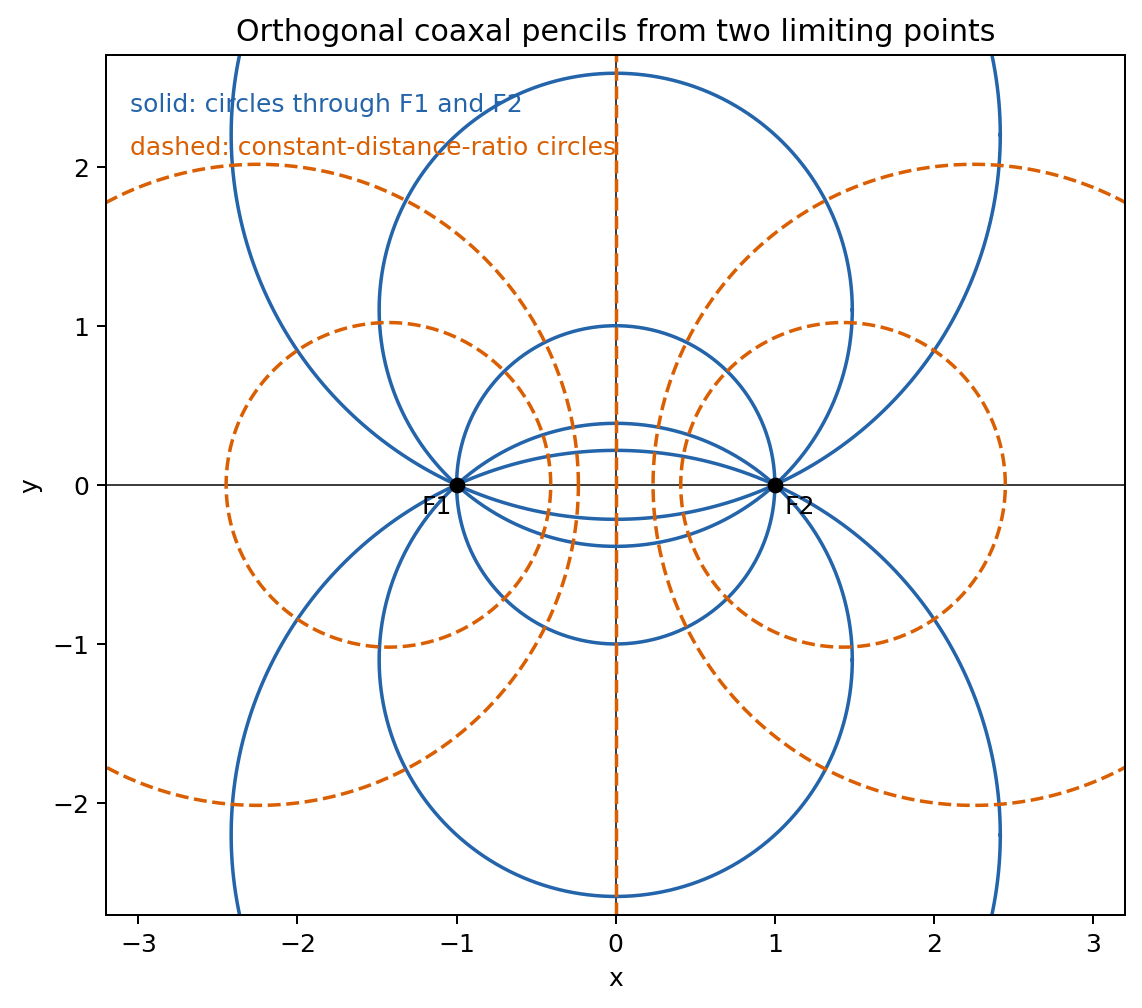

{'chapter': 6,
 'concept': 'orthogonal coaxal pencils',
 'intersecting_pencil_count': 5,
 'nonintersecting_pencil_count': 4,
 'tested_intersections': 40,
 'max_abs_cosine_of_intersection_angle': 5.551115123125783e-16}

In [4]:
F1 = np.array([-1.0, 0.0])
F2 = np.array([1.0, 0.0])
fig, ax = plt.subplots(figsize=(7.5, 6.2))
ax.set_aspect("equal")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-2.7, 2.7)
ax.axhline(0, color="black", lw=0.6)
ax.axvline(0, color="black", lw=0.6)
ax.scatter([F1[0], F2[0]], [F1[1], F2[1]], color="black", s=28, zorder=5)
ax.text(F1[0] - 0.22, F1[1] - 0.18, "F1")
ax.text(F2[0] + 0.06, F2[1] - 0.18, "F2")
ax.set_title("Orthogonal coaxal pencils from two limiting points")

intersecting = []
for t0 in [-2.2, -1.1, 0.0, 1.1, 2.2]:
    center = np.array([0.0, t0])
    radius = math.sqrt(1.0 + t0 * t0)
    intersecting.append((center, radius))
    pts = circle_points(center, radius, n=600)
    ax.plot(pts[:, 0], pts[:, 1], color="#2364aa", lw=1.4)

nonintersecting = []
for mu in [0.42, 0.62, 1.0 / 0.62, 1.0 / 0.42]:
    center, radius = apollonius_circle(F1, F2, mu)
    nonintersecting.append((center, radius, mu))
    pts = circle_points(center, radius, n=700)
    visible = (np.abs(pts[:, 0]) < 3.4) & (np.abs(pts[:, 1]) < 2.9)
    ax.plot(pts[visible, 0], pts[visible, 1], color="#d95f02", lw=1.4, linestyle="--")
ax.plot([0, 0], [-2.7, 2.7], color="#d95f02", lw=1.4, linestyle="--")

angle_cosines = []
for c0, r0 in intersecting:
    for c1, r1, _ in nonintersecting:
        pts = circle_intersections(c0, r0, c1, r1)
        for p0 in pts:
            v0 = (p0 - c0) / r0
            v1 = (p0 - c1) / r1
            angle_cosines.append(float(abs(np.dot(v0, v1))))

ax.text(-3.05, 2.35, "solid: circles through F1 and F2", color="#2364aa")
ax.text(-3.05, 2.08, "dashed: constant-distance-ratio circles", color="#d95f02")
ax.set_xlabel("x")
ax.set_ylabel("y")

check = {
    "chapter": CHAPTER_NO,
    "concept": "orthogonal coaxal pencils",
    "intersecting_pencil_count": len(intersecting),
    "nonintersecting_pencil_count": len(nonintersecting),
    "tested_intersections": len(angle_cosines),
    "max_abs_cosine_of_intersection_angle": float(max(angle_cosines)),
}
fig_path = artifact_path(CHAPTER_NO, "figures", "orthogonal_coaxal_pencils.png", BOOK_ROOT)
check_path = artifact_path(CHAPTER_NO, "checks", "orthogonal_coaxal_pencils_checks.json", BOOK_ROOT)
savefig(fig, fig_path)
write_json(check_path, check)
record(fig_path, "figure", "orthogonal and coaxal circle pencils")
record(check_path, "check", "orthogonal and coaxal circle pencils")
check_records["orthogonal_coaxal_pencils"] = check

display_artifact(fig_path, width=780)
check


## 4. The Circle of Apollonius

The Apollonius locus is the set of points whose distances from two fixed points are in a fixed ratio. In the notation used here, `|P - A_prime| = mu |P - A|`. For `mu = 1` the locus is the perpendicular bisector; for every other positive `mu` it is a circle. The table saved with the figure records the center and radius so the construction is inspectable without relying on the drawing.


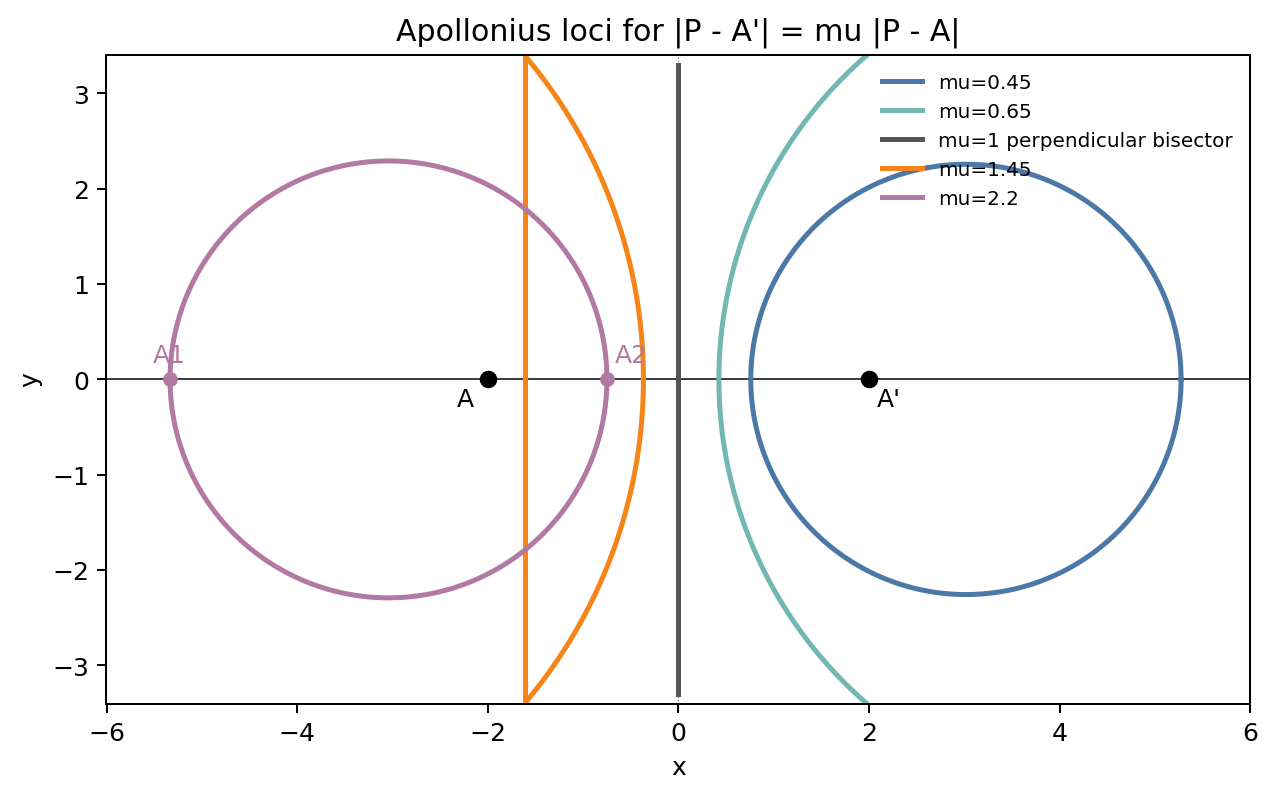

{'chapter': 6,
 'concept': 'Apollonius circle distance-ratio locus',
 'fixed_points': {'A': [-2.0, 0.0], 'A_prime': [2.0, 0.0]},
 'mu_values': [0.45, 0.65, 1.0, 1.45, 2.2],
 'max_ratio_error': 1.3322676295501878e-15}

In [5]:
A = np.array([-2.0, 0.0])
Aprime = np.array([2.0, 0.0])
mu_values = [0.45, 0.65, 1.0, 1.45, 2.2]
fig, ax = plt.subplots(figsize=(8.2, 5.8))
ax.set_aspect("equal")
ax.set_xlim(-6.0, 6.0)
ax.set_ylim(-3.4, 3.4)
ax.axhline(0, color="black", lw=0.6)
ax.axvline(0, color="#777777", lw=0.5, linestyle=":")
ax.scatter([A[0], Aprime[0]], [A[1], Aprime[1]], color="black", zorder=5)
ax.text(A[0] - 0.32, A[1] - 0.28, "A")
ax.text(Aprime[0] + 0.08, Aprime[1] - 0.28, "A'")
colors = ["#4c78a8", "#72b7b2", "#555555", "#f58518", "#b279a2"]
rows = []
max_ratio_error = 0.0
for mu, color in zip(mu_values, colors):
    center, radius = apollonius_circle(A, Aprime, mu)
    if center is None:
        ax.plot([0, 0], [-3.3, 3.3], color=color, lw=2.0, label="mu=1 perpendicular bisector")
        sample = np.column_stack([np.zeros(80), np.linspace(-3.0, 3.0, 80)])
        ratio = norm(sample - Aprime) / norm(sample - A)
        err = float(np.max(np.abs(ratio - mu)))
        rows.append({"mu": mu, "type": "line", "center_x": "", "center_y": "", "radius": "", "max_ratio_error": err})
    else:
        pts = circle_points(center, radius, n=800)
        visible = (np.abs(pts[:, 0]) <= 6.0) & (np.abs(pts[:, 1]) <= 3.4)
        ax.plot(pts[visible, 0], pts[visible, 1], color=color, lw=2.0, label=f"mu={mu:g}")
        theta = np.linspace(0.25, 2 * np.pi - 0.25, 120)
        sample = center + radius * np.column_stack([np.cos(theta), np.sin(theta)])
        ratio = norm(sample - Aprime) / norm(sample - A)
        err = float(np.max(np.abs(ratio - mu)))
        rows.append({
            "mu": mu,
            "type": "circle",
            "center_x": center[0],
            "center_y": center[1],
            "radius": radius,
            "max_ratio_error": err,
        })
        if abs(mu - 2.2) < 1e-12:
            ax.scatter([center[0] - radius, center[0] + radius], [0, 0], color=color, s=24, zorder=6)
            ax.text(center[0] - radius - 0.18, 0.18, "A1", color=color)
            ax.text(center[0] + radius + 0.08, 0.18, "A2", color=color)
    max_ratio_error = max(max_ratio_error, err)
ax.set_title("Apollonius loci for |P - A'| = mu |P - A|")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(frameon=False, fontsize=8, loc="upper right")

check = {
    "chapter": CHAPTER_NO,
    "concept": "Apollonius circle distance-ratio locus",
    "fixed_points": {"A": A.tolist(), "A_prime": Aprime.tolist()},
    "mu_values": mu_values,
    "max_ratio_error": max_ratio_error,
}
fig_path = artifact_path(CHAPTER_NO, "figures", "apollonius_ratio_loci.png", BOOK_ROOT)
table_path = artifact_path(CHAPTER_NO, "tables", "apollonius_loci.csv", BOOK_ROOT)
check_path = artifact_path(CHAPTER_NO, "checks", "apollonius_loci_checks.json", BOOK_ROOT)
savefig(fig, fig_path)
write_csv(table_path, rows)
write_json(check_path, check)
record(fig_path, "figure", "Apollonius distance-ratio loci")
record(table_path, "table", "Apollonius distance-ratio loci")
record(check_path, "check", "Apollonius distance-ratio loci")
check_records["apollonius_loci"] = check

display_artifact(fig_path, width=820)
display_artifact(table_path)
check


## 5. Circle-Preserving Transformations in the Inverse Plane

Once lines are treated as circles through the point at infinity, it becomes natural to study transformations that preserve the class of generalized circles. A Mobius map on the extended complex plane is a compact computational model for this part of the chapter. The map used below is deliberately not just a rotation or scaling, so the preservation of circles is not visually trivial.

The HTML artifact has two panels: sampled generalized circles before the map and their images after the map. The check fits each transformed sample to either a circle or a line, then records the smaller residual. A separate cross-ratio check guards the projective content of the transformation.


In [6]:
def mobius(z, a, b, c, d):
    return (a * z + b) / (c * z + d)

def complex_circle(center, radius, n=500):
    t = np.linspace(0, 2 * np.pi, n)
    return center + radius * np.exp(1j * t)

def complex_line(point, direction, span=(-2.6, 2.6), n=500):
    t = np.linspace(span[0], span[1], n)
    return point + t * direction

def as_points(z):
    return np.column_stack([np.real(z), np.imag(z)])

def generalized_circle_residual(z):
    pts = as_points(z)
    _, _, circle_resid = fit_circle(pts)
    _, _, line_resid = fit_line(pts)
    if line_resid < circle_resid:
        return "line", float(line_resid)
    return "circle", float(circle_resid)

def cross_ratio(z1, z2, z3, z4):
    return ((z1 - z3) * (z2 - z4)) / ((z1 - z4) * (z2 - z3))

a = 1.0 + 0.22j
b = -0.42 + 0.34j
c = 0.18 - 0.11j
d = 1.08 + 0.05j
samples = {
    "unit circle": complex_circle(0.0 + 0.0j, 1.0),
    "offset circle": complex_circle(0.55 + 0.25j, 0.46),
    "horizontal line": complex_line(-0.15 + 0.62j, 1.0 + 0.0j),
    "slanted line": complex_line(-0.85 - 0.28j, 1.0 + 0.48j),
}
colors = ["#4c78a8", "#f58518", "#54a24b", "#b279a2"]
fig = make_subplots(rows=1, cols=2, subplot_titles=("before Mobius map", "after Mobius map"))
fit_checks = {}
for (name, z), color in zip(samples.items(), colors):
    w = mobius(z, a, b, c, d)
    fig.add_trace(go.Scatter(x=np.real(z), y=np.imag(z), mode="lines", name=name, line=dict(color=color, width=3)), row=1, col=1)
    fig.add_trace(go.Scatter(x=np.real(w), y=np.imag(w), mode="lines", name=f"image of {name}", line=dict(color=color, width=3), showlegend=False), row=1, col=2)
    image_type, residual = generalized_circle_residual(w)
    fit_checks[name] = {"image_type": image_type, "fit_residual": residual}

pole = -d / c
fig.add_trace(go.Scatter(x=[pole.real], y=[pole.imag], mode="markers+text", text=["pole"], textposition="top center", marker=dict(color="black", size=8), name="pole"), row=1, col=1)
fig.update_xaxes(scaleanchor="y", scaleratio=1, row=1, col=1)
fig.update_xaxes(scaleanchor="y2", scaleratio=1, row=1, col=2)
fig.update_layout(width=950, height=470, title="Generalized circles under a Mobius transformation", template="plotly_white")

zpts = np.array([-1.2 + 0.35j, -0.25 - 0.8j, 0.74 + 0.25j, 1.35 - 0.45j])
wpts = mobius(zpts, a, b, c, d)
cr_error = abs(cross_ratio(*zpts) - cross_ratio(*wpts))
max_fit_residual = float(max(item["fit_residual"] for item in fit_checks.values()))
check = {
    "chapter": CHAPTER_NO,
    "concept": "circle-preserving Mobius transformation",
    "matrix": [[a.real, a.imag, b.real, b.imag], [c.real, c.imag, d.real, d.imag]],
    "determinant_abs": float(abs(a * d - b * c)),
    "max_generalized_circle_fit_residual": max_fit_residual,
    "cross_ratio_error": float(cr_error),
    "fit_checks": fit_checks,
}
html_path = artifact_path(CHAPTER_NO, "html", "mobius_circle_preservation.html", BOOK_ROOT)
check_path = artifact_path(CHAPTER_NO, "checks", "mobius_circle_preservation_checks.json", BOOK_ROOT)
fig.write_html(str(html_path), include_plotlyjs="cdn", full_html=True)
write_json(check_path, check)
record(html_path, "html", "circle-preserving Mobius transformation")
record(check_path, "check", "circle-preserving Mobius transformation")
check_records["mobius_circle_preservation"] = check

display_artifact(html_path, width=950)
check


{'chapter': 6,
 'concept': 'circle-preserving Mobius transformation',
 'matrix': [[1.0, 0.22, -0.42, 0.34], [0.18, -0.11, 1.08, 0.05]],
 'determinant_abs': 1.121768193523065,
 'max_generalized_circle_fit_residual': 1.7763568394002505e-15,
 'cross_ratio_error': 2.2887833992611187e-16,
 'fit_checks': {'unit circle': {'image_type': 'circle',
   'fit_residual': 6.661338147750939e-16},
  'offset circle': {'image_type': 'circle',
   'fit_residual': 7.771561172376096e-16},
  'horizontal line': {'image_type': 'circle',
   'fit_residual': 1.7763568394002505e-15},
  'slanted line': {'image_type': 'circle',
   'fit_residual': 1.7763568394002505e-15}}}

## 6. Sphere Inversion and Stereographic Projection

Sphere inversion uses the same product rule in three dimensions. The most useful chapter picture is stereographic projection: choose the north pole `N` of a sphere, invert a tangent plane from `N` with radius equal to the diameter, and every point of the plane lands on the sphere along the same ray from `N`.

This view also explains why the inverse plane needs a point at infinity. The projection center has no ordinary image on the plane; it corresponds to the direction in which projected points run away without bound. Lines and circles in the plane become circles on the sphere, with lines becoming circles through `N`.


In [7]:
def stereographic_from_tangent_plane(points_xy):
    # Plane z = -1, projection/inversion center N = (0, 0, 1), radius 2.
    xy = np.asarray(points_xy, dtype=float)
    plane = np.column_stack([xy[:, 0], xy[:, 1], -np.ones(len(xy))])
    N = np.array([0.0, 0.0, 1.0])
    return invert_points3(plane, radius=2.0, center=N), plane

u = np.linspace(0, 2 * np.pi, 70)
v = np.linspace(0, np.pi, 36)
X = np.outer(np.cos(u), np.sin(v))
Y = np.outer(np.sin(u), np.sin(v))
Z = np.outer(np.ones_like(u), np.cos(v))
fig = go.Figure()
fig.add_trace(go.Surface(x=X, y=Y, z=Z, colorscale=[[0, "rgba(120,160,210,0.20)"], [1, "rgba(120,160,210,0.20)"]], showscale=False, name="unit sphere", opacity=0.35))
plane_x, plane_y = np.meshgrid(np.linspace(-2.4, 2.4, 7), np.linspace(-2.4, 2.4, 7))
plane_z = -np.ones_like(plane_x)
fig.add_trace(go.Surface(x=plane_x, y=plane_y, z=plane_z, showscale=False, opacity=0.18, colorscale=[[0, "rgba(180,180,180,0.25)"], [1, "rgba(180,180,180,0.25)"]], name="tangent plane"))

line_xy = np.column_stack([np.linspace(-2.2, 2.2, 240), np.full(240, 0.82)])
line_sphere, line_plane = stereographic_from_tangent_plane(line_xy)
circle_xy = np.column_stack([0.7 + 0.68 * np.cos(np.linspace(0, 2 * np.pi, 260)), -0.45 + 0.68 * np.sin(np.linspace(0, 2 * np.pi, 260))])
circle_sphere, circle_plane = stereographic_from_tangent_plane(circle_xy)
fig.add_trace(go.Scatter3d(x=line_plane[:, 0], y=line_plane[:, 1], z=line_plane[:, 2], mode="lines", line=dict(color="#f58518", width=5), name="plane line"))
fig.add_trace(go.Scatter3d(x=line_sphere[:, 0], y=line_sphere[:, 1], z=line_sphere[:, 2], mode="lines", line=dict(color="#f58518", width=6), name="image circle through N"))
fig.add_trace(go.Scatter3d(x=circle_plane[:, 0], y=circle_plane[:, 1], z=circle_plane[:, 2], mode="lines", line=dict(color="#54a24b", width=5), name="plane circle"))
fig.add_trace(go.Scatter3d(x=circle_sphere[:, 0], y=circle_sphere[:, 1], z=circle_sphere[:, 2], mode="lines", line=dict(color="#54a24b", width=6), name="image circle"))
N = np.array([0.0, 0.0, 1.0])
S = np.array([0.0, 0.0, -1.0])
fig.add_trace(go.Scatter3d(x=[N[0], S[0]], y=[N[1], S[1]], z=[N[2], S[2]], mode="markers+text", text=["N", "S"], textposition="top center", marker=dict(color="black", size=4), name="poles"))
for idx in [35, 120, 200]:
    p0 = line_plane[idx]
    q0 = line_sphere[idx]
    fig.add_trace(go.Scatter3d(x=[N[0], p0[0]], y=[N[1], p0[1]], z=[N[2], p0[2]], mode="lines", line=dict(color="rgba(30,30,30,0.35)", width=2), showlegend=False))
    fig.add_trace(go.Scatter3d(x=[q0[0]], y=[q0[1]], z=[q0[2]], mode="markers", marker=dict(color="#f58518", size=3), showlegend=False))

sphere_residual = float(np.max(np.abs(np.sum(line_sphere * line_sphere, axis=1) - 1.0)))
plane_dist = norm(line_plane - N)
sphere_dist = norm(line_sphere - N)
product_residual = float(np.max(np.abs(plane_dist * sphere_dist - 4.0)))
collinearity = np.cross(line_plane - N, line_sphere - N)
collinearity_residual = float(np.max(norm(collinearity)))
check = {
    "chapter": CHAPTER_NO,
    "concept": "sphere inversion and stereographic projection",
    "projection_center": N.tolist(),
    "inversion_radius": 2.0,
    "max_sphere_equation_residual": sphere_residual,
    "max_NP_times_NP_prime_minus_radius_squared": product_residual,
    "max_ray_collinearity_residual": collinearity_residual,
}
fig.update_layout(
    width=900,
    height=720,
    title="Stereographic projection as sphere inversion from the north pole",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    template="plotly_white",
)
html_path = artifact_path(CHAPTER_NO, "html", "sphere_inversion_stereographic.html", BOOK_ROOT)
check_path = artifact_path(CHAPTER_NO, "checks", "sphere_inversion_stereographic_checks.json", BOOK_ROOT)
fig.write_html(str(html_path), include_plotlyjs="cdn", full_html=True)
write_json(check_path, check)
record(html_path, "html", "sphere inversion and stereographic projection")
record(check_path, "check", "sphere inversion and stereographic projection")
check_records["sphere_inversion_stereographic"] = check

display_artifact(html_path, width=900)
check


{'chapter': 6,
 'concept': 'sphere inversion and stereographic projection',
 'projection_center': [0.0, 0.0, 1.0],
 'inversion_radius': 2.0,
 'max_sphere_equation_residual': 4.440892098500626e-16,
 'max_NP_times_NP_prime_minus_radius_squared': 8.881784197001252e-16,
 'max_ray_collinearity_residual': 3.1401849173675503e-16}

## 7. Elliptic-Plane Intuition from Great Circles

The elliptic plane can be read from a sphere by identifying antipodal points. Its lines are great circles, except each pair of antipodal points on a great circle is counted as one elliptic point. Gnomonic projection sends great circles to straight lines, so it gives a quick bridge from the sphere picture back to a plane drawing. It does not preserve distances or angles; it preserves the fact that the sides are lines.

The numerical scaffold below checks Girard's formula for the chosen spherical triangle: area equals `A + B + C - pi`. This is the area statement that survives in the elliptic-plane model after antipodal identification.


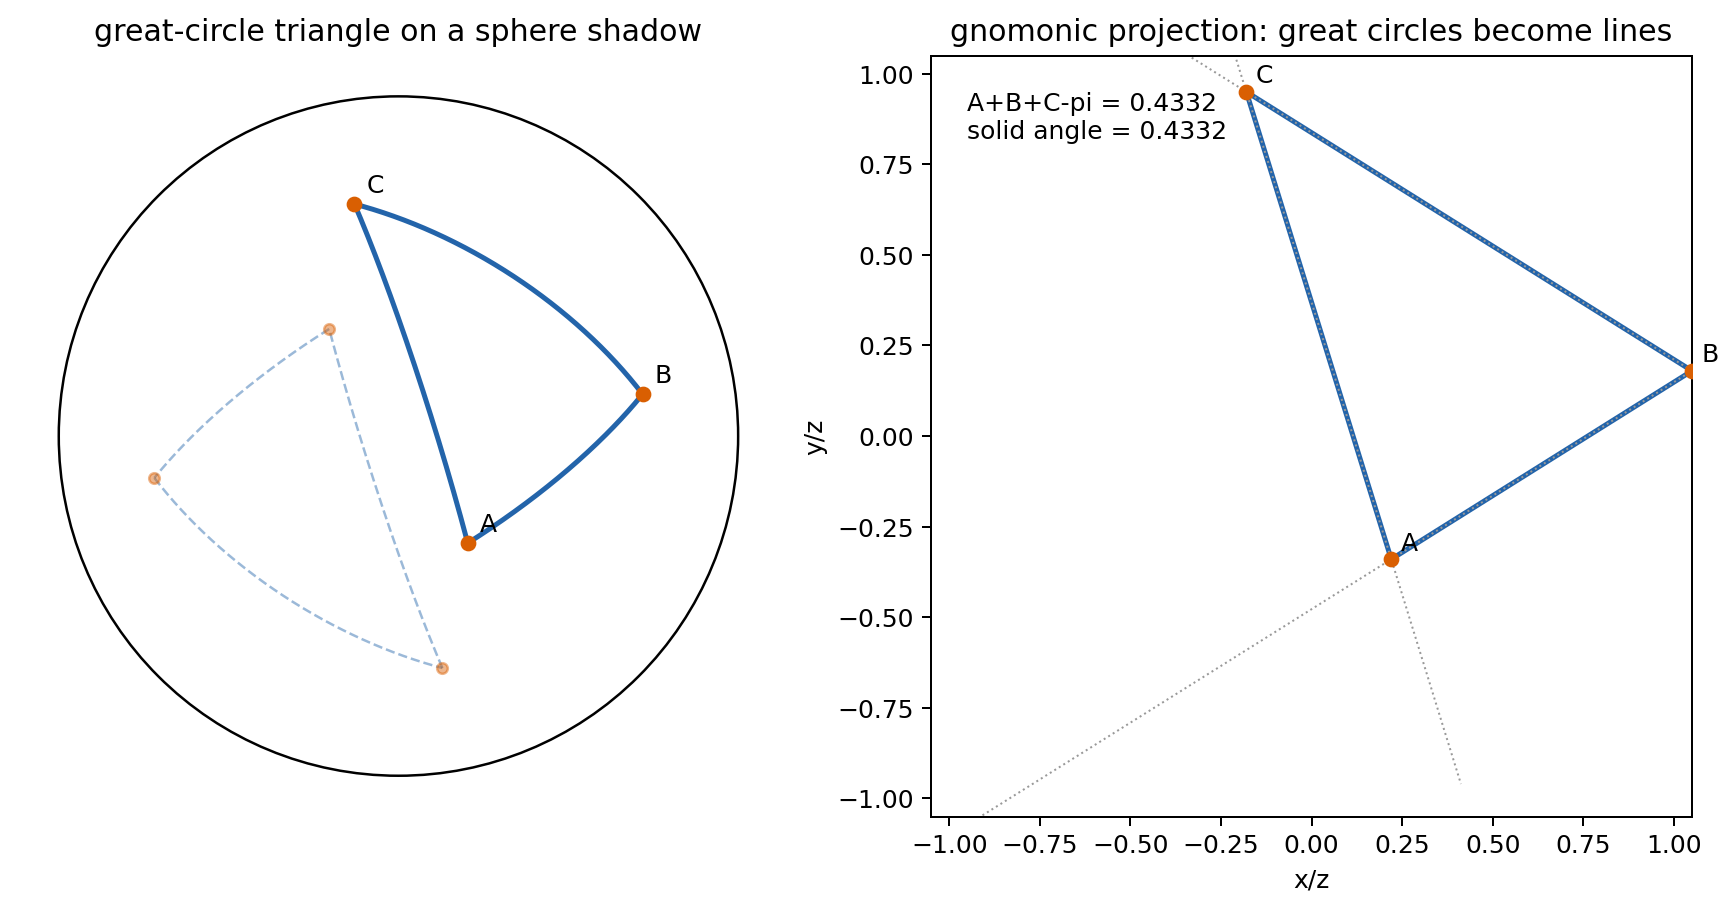

{'chapter': 6,
 'concept': 'elliptic plane from antipodal great circles',
 'angles_radians': [1.290317787611122, 1.4577882545341825, 0.8266957947808977],
 'spherical_excess': 0.4332091833364089,
 'solid_angle_area': 0.4332091833364088,
 'girard_area_residual': 1.1102230246251565e-16}

In [8]:
def unit(v):
    v = np.asarray(v, dtype=float)
    return v / np.linalg.norm(v)

def slerp(a, b, n=120):
    a = unit(a)
    b = unit(b)
    omega = math.acos(float(np.clip(np.dot(a, b), -1.0, 1.0)))
    t = np.linspace(0.0, 1.0, n)
    if omega < 1e-12:
        return np.repeat(a[None, :], n, axis=0)
    return (np.sin((1 - t) * omega)[:, None] * a + np.sin(t * omega)[:, None] * b) / math.sin(omega)

def spherical_angle(a, b, c):
    a = unit(a); b = unit(b); c = unit(c)
    u = b - np.dot(a, b) * a
    v = c - np.dot(a, c) * a
    u = unit(u); v = unit(v)
    return math.acos(float(np.clip(np.dot(u, v), -1.0, 1.0)))

def solid_angle_area(a, b, c):
    a = unit(a); b = unit(b); c = unit(c)
    det = float(np.linalg.det(np.vstack([a, b, c])))
    denom = 1.0 + float(np.dot(a, b) + np.dot(b, c) + np.dot(c, a))
    return 2.0 * math.atan2(abs(det), denom)

A3 = unit([0.22, -0.34, 1.0])
B3 = unit([1.05, 0.18, 1.0])
C3 = unit([-0.18, 0.95, 1.0])
arcs = [(A3, B3), (B3, C3), (C3, A3)]
angles = [spherical_angle(A3, B3, C3), spherical_angle(B3, C3, A3), spherical_angle(C3, A3, B3)]
excess = sum(angles) - math.pi
solid_area = solid_angle_area(A3, B3, C3)

fig = plt.figure(figsize=(12.0, 5.6))
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_aspect("equal")
ax1.set_title("great-circle triangle on a sphere shadow")
ax1.add_patch(Circle((0, 0), 1.0, fill=False, color="black", lw=1.0))
for a0, b0 in arcs:
    pts = slerp(a0, b0, n=160)
    ax1.plot(pts[:, 0], pts[:, 1], color="#2364aa", lw=2.0)
    antipodal = -pts
    ax1.plot(antipodal[:, 0], antipodal[:, 1], color="#2364aa", lw=1.0, linestyle="--", alpha=0.45)
for label, p0 in zip(["A", "B", "C"], [A3, B3, C3]):
    ax1.scatter([p0[0]], [p0[1]], color="#d95f02", s=28, zorder=4)
    ax1.text(p0[0] + 0.035, p0[1] + 0.035, label)
    ax1.scatter([-p0[0]], [-p0[1]], color="#d95f02", s=18, alpha=0.45, zorder=3)
ax1.set_xlim(-1.12, 1.12); ax1.set_ylim(-1.12, 1.12)
ax1.axis("off")

ax2 = fig.add_subplot(1, 2, 2)
ax2.set_aspect("equal")
ax2.set_title("gnomonic projection: great circles become lines")
proj = []
for p0 in [A3, B3, C3]:
    proj.append(np.array([p0[0] / p0[2], p0[1] / p0[2]]))
proj = np.array(proj)
closed = np.vstack([proj, proj[0]])
ax2.plot(closed[:, 0], closed[:, 1], color="#2364aa", lw=2.0)
for label, p0 in zip(["A", "B", "C"], proj):
    ax2.scatter([p0[0]], [p0[1]], color="#d95f02", s=28, zorder=4)
    ax2.text(p0[0] + 0.025, p0[1] + 0.025, label)
for i in range(3):
    p0 = proj[i]
    q0 = proj[(i + 1) % 3]
    direction = q0 - p0
    direction = direction / np.linalg.norm(direction)
    t = np.linspace(-2.0, 2.0, 2)
    line = p0 + t[:, None] * direction
    ax2.plot(line[:, 0], line[:, 1], color="#999999", lw=0.8, linestyle=":")
ax2.text(-0.95, 0.95, f"A+B+C-pi = {excess:.4f}\nsolid angle = {solid_area:.4f}", fontsize=10, va="top")
ax2.set_xlim(-1.05, 1.05); ax2.set_ylim(-1.05, 1.05)
ax2.set_xlabel("x/z")
ax2.set_ylabel("y/z")

check = {
    "chapter": CHAPTER_NO,
    "concept": "elliptic plane from antipodal great circles",
    "angles_radians": [float(a0) for a0 in angles],
    "spherical_excess": float(excess),
    "solid_angle_area": float(solid_area),
    "girard_area_residual": float(abs(excess - solid_area)),
}
fig_path = artifact_path(CHAPTER_NO, "figures", "elliptic_gnomonic_triangle.png", BOOK_ROOT)
check_path = artifact_path(CHAPTER_NO, "checks", "elliptic_gnomonic_triangle_checks.json", BOOK_ROOT)
savefig(fig, fig_path)
write_json(check_path, check)
record(fig_path, "figure", "elliptic plane great-circle intuition")
record(check_path, "check", "elliptic plane great-circle intuition")
check_records["elliptic_gnomonic_triangle"] = check

display_artifact(fig_path, width=900)
check


## Applied Lab: Stress-Test One Hypothesis

The computations above are intentionally small enough to change. A useful lab is to pick one hypothesis and alter it by one notch.

- Move the inversion center away from the origin and confirm that the product rule must use distances from the new center.
- Change the fixed points in the Apollonius section and verify that `mu = 1` is still a line while the other level sets are circles.
- Move a sampled curve through the Mobius pole and watch the fitted image switch between a large circle and a line.
- In the stereographic section, replace a plane line by another plane line and confirm that its sphere image still passes through the projection center.

The lab cell below exposes two parameters without regenerating every artifact: the Apollonius ratio and the inversion radius. It is not a proof, but it is a fast way to detect which measurements are structural.


In [9]:
def apollonius_probe(mu=1.7, A=(-2.0, 0.0), B=(2.0, 0.0)):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    center, radius = apollonius_circle(A, B, mu)
    if center is None:
        sample = np.column_stack([np.full(25, (A[0] + B[0]) / 2.0), np.linspace(-2.5, 2.5, 25)])
        locus_type = "line"
    else:
        sample = circle_points(center, radius, n=80)
        locus_type = "circle"
    ratio = norm(sample - B) / norm(sample - A)
    return {
        "mu": float(mu),
        "locus_type": locus_type,
        "max_ratio_error": float(np.max(np.abs(ratio - mu))),
    }

def inversion_probe(radius=1.35):
    pts = np.array([[0.6, 1.4], [-1.8, 0.5], [2.2, -0.7]])
    inv = invert_points(pts, radius=radius)
    back = invert_points(inv, radius=radius)
    return {
        "radius": float(radius),
        "max_product_error": float(np.max(np.abs(norm(pts) * norm(inv) - radius * radius))),
        "max_involution_error": float(np.max(norm(back - pts))),
    }

lab_result = {
    "apollonius_probe": apollonius_probe(mu=1.7),
    "inversion_probe": inversion_probe(radius=1.35),
}
assert lab_result["apollonius_probe"]["max_ratio_error"] < 1e-12
assert lab_result["inversion_probe"]["max_product_error"] < 1e-12
assert lab_result["inversion_probe"]["max_involution_error"] < 1e-12
lab_result


{'apollonius_probe': {'mu': 1.7,
  'locus_type': 'circle',
  'max_ratio_error': 6.661338147750939e-16},
 'inversion_probe': {'radius': 1.35,
  'max_product_error': 2.220446049250313e-16,
  'max_involution_error': 0.0}}

## Final Sanity Checks

The final cell writes a chapter summary JSON and a manifest table, then asserts that every generated artifact exists, is nonempty, and is backed by a concept-specific invariant. The checks are deliberately stricter than visual inspection: a pretty diagram is not enough if the product rule, orthogonality, ratio relation, circle preservation, sphere equation, or elliptic area identity fails.


In [10]:
# Small symbolic scaffold for the line-to-circle rule under unit inversion.
x, y, a_sym = sp.symbols("x y a", nonzero=True, real=True)
X = x / (x**2 + y**2)
Y = y / (x**2 + y**2)
line_to_circle_identity = sp.simplify((X - 1 / (2 * a_sym))**2 + Y**2 - (1 / (2 * a_sym))**2)
line_to_circle_on_source = sp.simplify(line_to_circle_identity.subs(x, a_sym))
assert line_to_circle_on_source == 0

thresholds = {
    "inversion_product": check_records["inversion_grid"]["max_product_error"],
    "inversion_involution": check_records["inversion_grid"]["max_involution_error"],
    "line_circle_residual": check_records["line_circle_images"]["max_residual"],
    "orthogonal_cosine": check_records["orthogonal_coaxal_pencils"]["max_abs_cosine_of_intersection_angle"],
    "apollonius_ratio": check_records["apollonius_loci"]["max_ratio_error"],
    "mobius_fit": check_records["mobius_circle_preservation"]["max_generalized_circle_fit_residual"],
    "mobius_cross_ratio": check_records["mobius_circle_preservation"]["cross_ratio_error"],
    "sphere_equation": check_records["sphere_inversion_stereographic"]["max_sphere_equation_residual"],
    "sphere_product": check_records["sphere_inversion_stereographic"]["max_NP_times_NP_prime_minus_radius_squared"],
    "elliptic_girard": check_records["elliptic_gnomonic_triangle"]["girard_area_residual"],
}
assert thresholds["inversion_product"] < 1e-12
assert thresholds["inversion_involution"] < 1e-12
assert thresholds["line_circle_residual"] < 1e-10
assert thresholds["orthogonal_cosine"] < 1e-10
assert thresholds["apollonius_ratio"] < 1e-12
assert thresholds["mobius_fit"] < 1e-10
assert thresholds["mobius_cross_ratio"] < 1e-12
assert thresholds["sphere_equation"] < 1e-12
assert thresholds["sphere_product"] < 1e-12
assert thresholds["elliptic_girard"] < 1e-12

manifest_path = artifact_path(CHAPTER_NO, "tables", "artifact_manifest.csv", BOOK_ROOT)
summary_path = artifact_path(CHAPTER_NO, "checks", "visual_summary.json", BOOK_ROOT)
manifest_rows = list(artifact_records.values())
write_csv(manifest_path, manifest_rows)
record(manifest_path, "table", "chapter artifact manifest")

summary = {
    "chapter": CHAPTER_NO,
    "title": chapter["title"],
    "source_span": {"printed_pages": "77-95", "pdf_pages": "95-113"},
    "storyboard_items": [
        "circle inversion grid and point pairs",
        "inversion of lines and circles",
        "orthogonal and coaxal circle pencils",
        "Apollonius distance-ratio loci",
        "circle-preserving Mobius transformation",
        "sphere inversion and stereographic projection",
        "elliptic plane great-circle intuition",
    ],
    "libraries": {
        "numpy": "coordinate sampling and numeric invariants",
        "matplotlib": "durable 2D construction diagrams",
        "plotly": "inspectable 2D/3D HTML artifacts for Mobius and stereographic views",
        "sympy": "exact line-to-circle identity check",
    },
    "artifacts": sorted(artifact_records.keys()),
    "checks": thresholds,
    "symbolic_identity": "unit inversion sends the line x=a to the circle centered at (1/(2a), 0) with radius 1/(2a)",
}
write_json(summary_path, summary)
record(summary_path, "check", "chapter visual summary")

all_paths = [BOOK_ROOT / item["path"] for item in artifact_records.values()]
assert_artifacts(all_paths, min_bytes=100)
assert len([p for p in all_paths if p.suffix.lower() in {".png", ".html", ".svg"}]) >= 4

final_sanity = {
    "artifact_count": len(all_paths),
    "visual_artifact_count": len([p for p in all_paths if p.suffix.lower() in {".png", ".html", ".svg"}]),
    "max_threshold": max(thresholds.values()),
    "summary_path": rel(summary_path),
    "manifest_path": rel(manifest_path),
}
final_sanity


{'artifact_count': 18,
 'visual_artifact_count': 7,
 'max_threshold': 1.9984014443252818e-15,
 'summary_path': 'artifacts/chapter-06/checks/visual_summary.json',
 'manifest_path': 'artifacts/chapter-06/tables/artifact_manifest.csv'}

## Takeaways

Circle inversion is a product rule with a strong visual consequence: the inverse plane treats lines and circles as one family of generalized circles. Orthogonal and coaxal pencils make this family navigable, and Apollonius circles show how a metric condition becomes a circle. Mobius transformations give the circle-preserving viewpoint a compact algebraic test. In space, the same inversion rule explains stereographic projection, while great circles and antipodal identification give a first computational model of the elliptic plane.
